# Experiment 06 — Motor Commands

```
Language comprehension
      ↓
Meaning + memory + emotion + social context
      ↓
Response planning
      ↓
Word and sentence construction
      ↓
Motor commands   <- this notebook
```

The last stage: turning chosen words into the physical movements that actually
produce speech. Real articulation involves jaw, tongue, and lips moving through a
continuous trajectory — nothing like a discrete symbol. This stage maps each word
to a 3-dimensional "motor vector" (a toy stand-in for jaw height, lip rounding, and
tongue frontness) and looks at the trajectory across a whole utterance.

Standalone as always: input words are typed in directly here, not generated by
stage 05's model.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0);

## A toy grapheme-to-articulation heuristic

Real grapheme-to-phoneme-to-articulation mapping is a genuinely hard problem
("ough" alone is pronounced 8+ different ways in English). We're not attempting
that — instead we hand-define a crude but *smooth, deterministic* heuristic
straight from spelling, purely so we have a real target to train against:

- **jaw_height** ~ fraction of letters that are vowels (`aeiou`)
- **lip_rounding** ~ fraction of letters that are `o` or `u`
- **tongue_front** ~ fraction of letters that are `i` or `e`

Unlike stage 05's plan -> sentence mapping (an arbitrary lookup with no shared
structure between examples), this target is a *smooth function of spelling* — two
similarly-spelled words should get similar motor vectors. That structure is what
we'll check for at the end: does a network trained on some words predict sensibly
for words it never saw?

In [2]:
vowels = set("aeiou")
round_letters = set("ou")
front_letters = set("ie")


def target_motor(word):
    n = len(word)
    jaw = sum(c in vowels for c in word) / n
    lips = sum(c in round_letters for c in word) / n
    tongue = sum(c in front_letters for c in word) / n
    return [jaw, lips, tongue]


word_list = sorted(set("""
the meeting starts at three yes that is correct the answer forty two
it is on the table could you say that again which one do you mean
can you be more specific did you mean today or tomorrow that sounds
really hard i am sorry you feel that way it makes sense to be upset
i hear you and that matters press the button twice turn left at the
corner save the file first restart the device now hello there friend
good morning everyone hi how are you nice to meet you what time where
are you going she walked to school dogs are loyal animals please close
the door sit down now bring me some water turn off the lights cat dog
run jump quickly slowly beautiful wonderful yesterday tomorrow window
garden mountain river
""".split()))
print(f"{len(word_list)} unique words")

103 unique words


## Architecture: character embeddings, mean-pooled, regressed to motor space

Each letter gets a learned embedding; a word's embeddings are masked-mean-pooled
(so padding doesn't dilute short words) and projected to 3 motor values through a
small MLP with a final `sigmoid` (targets are all in [0, 1]). The network has to
*discover* from data which letters push jaw/lips/tongue up or down — it isn't
handed the vowel-counting rule directly, only raw characters.

In [3]:
char_to_id = {c: i for i, c in enumerate("abcdefghijklmnopqrstuvwxyz")}
pad_id = 26


def encode_word(word, max_len):
    ids = [char_to_id.get(c, pad_id) for c in word]
    mask = [1.0] * len(word)
    pad_amount = max_len - len(word)
    return ids + [pad_id] * pad_amount, mask + [0.0] * pad_amount


class MotorPlanner(nn.Module):
    def __init__(self, n_chars=27, char_dim=8, hidden_dim=16, motor_dim=3):
        super().__init__()
        self.char_embed = nn.Embedding(n_chars, char_dim, padding_idx=pad_id)
        self.to_motor = nn.Sequential(
            nn.Linear(char_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, motor_dim),
        )

    def forward(self, char_ids, mask):
        embs = self.char_embed(char_ids)                       # (N, L, char_dim)
        mask = mask.unsqueeze(-1)                                # (N, L, 1)
        pooled = (embs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return torch.sigmoid(self.to_motor(pooled))               # (N, motor_dim), each in [0, 1]


model = MotorPlanner()
print(model)

MotorPlanner(
  (char_embed): Embedding(27, 8, padding_idx=26)
  (to_motor): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)


## Train/test split and training

80/20 split by word, MSE regression, Adam. The test words are never seen during training.

In [4]:
import random
random.seed(0)
shuffled = word_list.copy()
random.shuffle(shuffled)
split = int(0.8 * len(shuffled))
train_words, test_words = shuffled[:split], shuffled[split:]


def make_batch(words):
    max_len = max(len(w) for w in words)
    ids, masks, targets = [], [], []
    for w in words:
        i, m = encode_word(w, max_len)
        ids.append(i)
        masks.append(m)
        targets.append(target_motor(w))
    return torch.tensor(ids), torch.tensor(masks), torch.tensor(targets, dtype=torch.float32)


train_ids, train_mask, train_targets = make_batch(train_words)
test_ids, test_mask, test_targets = make_batch(test_words)

optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
losses = []
for step in range(300):
    pred = model(train_ids, train_mask)
    loss = F.mse_loss(pred, train_targets)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

with torch.no_grad():
    test_mse = F.mse_loss(model(test_ids, test_mask), test_targets).item()

print(f"{len(train_words)} train words, {len(test_words)} test words")
print(f"train MSE: {losses[0]:.4f} -> {losses[-1]:.5f}")
print(f"held-out test MSE: {test_mse:.5f}")

82 train words, 21 test words
train MSE: 0.1125 -> 0.00009
held-out test MSE: 0.00380


## An articulatory trajectory across an utterance

Feed each word of a short sentence through the trained network in order and plot
the resulting jaw/lip/tongue trajectory — a toy stand-in for what stage 06 would
actually hand off to a speech articulator.

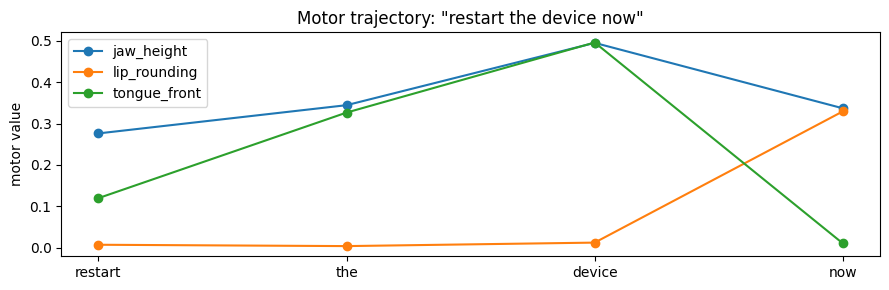

In [5]:
def utterance_trajectory(sentence):
    words = sentence.split()
    max_len = max(len(w) for w in words)
    ids, masks = [], []
    for w in words:
        i, m = encode_word(w, max_len)
        ids.append(i)
        masks.append(m)
    with torch.no_grad():
        motor = model(torch.tensor(ids), torch.tensor(masks))
    return words, motor


sentence = "restart the device now"
words, motor = utterance_trajectory(sentence)

plt.figure(figsize=(9, 3))
plt.plot(motor[:, 0], marker="o", label="jaw_height")
plt.plot(motor[:, 1], marker="o", label="lip_rounding")
plt.plot(motor[:, 2], marker="o", label="tongue_front")
plt.xticks(range(len(words)), words)
plt.ylabel("motor value")
plt.title(f'Motor trajectory: "{sentence}"')
plt.legend()
plt.tight_layout()
plt.show()

## What this hands off, and how it differs from stage 05

A per-word (in a real system, per-phoneme, at a much finer time resolution) motor
trajectory — the actual physical instructions, closing the pipeline from raw
language in to movement out.

The test MSE above is the number that actually matters here: stage 05 memorized
(it could only ever reproduce one of 4 exact training sentences), because mapping
an arbitrary discrete plan to an arbitrary discrete sentence has no shared
structure between examples. This stage's target — vowel/rounding/frontness ratios —
*is* a smooth function of spelling, so genuinely unseen words (`test_words` above)
should get sensible, not memorized, predictions, roughly matching their true
`target_motor` values. Whether that held here is exactly what the held-out MSE
measures — a small number means the character embeddings picked up real,
transferable spelling structure, not a lookup table.